# Persistent spatial bias and local feature analysis

This notebook asks where U-Net and Transformer have persistent errors, then relates those error patterns to local features such as elevation, slope, roughness, local relief, aspect, and urban fraction.

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "figure.dpi": 130,
})

fig_dir = Path("../figures/spatial_bias_local_features")
fig_dir.mkdir(parents=True, exist_ok=True)

ds_test = xr.open_dataset("../.data/downscaling_splits/test_norm.nc")
ds_unet = xr.open_dataset("../outputs/test_predictions.nc")
ds_tf = xr.open_dataset("../outputs/test_predictions_transformer_t_elev_oscar.nc")
ds_topo = xr.open_dataset("../.data/ETOPO2/topography_features_on_gridmet_masked.nc")
ds_urban = xr.open_dataset("../.data/Zenodo/urban_fraction_on_gridmet_masked_norm.nc")

common_time = np.intersect1d(ds_test["time"].values, ds_unet["time"].values)
common_time = np.intersect1d(common_time, ds_tf["time"].values)

truth = ds_test["tmax_highres"].sel(time=common_time)
interp = ds_test["tmax_lowres_interp"].sel(time=common_time)
unet = ds_unet["pred_tmax_highres"].sel(time=common_time)
tf = ds_tf["pred_tmax_highres"].sel(time=common_time)
mask = ds_test["valid_mask"].astype(bool)

def kelvin_to_celsius_if_needed(da):
    val = float(np.nanmean(da.where(mask).values))
    return da - 273.15 if val > 100 else da

truth = kelvin_to_celsius_if_needed(truth)
interp = kelvin_to_celsius_if_needed(interp)
unet = kelvin_to_celsius_if_needed(unet)
tf = kelvin_to_celsius_if_needed(tf)

models = {
    "Interpolation": interp,
    "U-Net T+Elev": unet,
    "Transformer T+Elev": tf,
}

print("Common test days:", len(common_time))

Common test days: 368


In [2]:
def spatial_nanmean(da):
    arr = da.where(mask).values
    return xr.DataArray(
        np.nanmean(arr, axis=0),
        coords={"lat": da["lat"], "lon": da["lon"]},
        dims=("lat", "lon"),
    ).where(mask)

bias_maps = {name: spatial_nanmean(pred - truth) for name, pred in models.items()}
rmse_maps = {name: spatial_nanmean((pred - truth) ** 2) ** 0.5 for name, pred in models.items()}

tf_rmse_improve_vs_unet = rmse_maps["U-Net T+Elev"] - rmse_maps["Transformer T+Elev"]
tf_abs_bias_improve_vs_unet = np.abs(bias_maps["U-Net T+Elev"]) - np.abs(bias_maps["Transformer T+Elev"])

print("Mean spatial RMSE")
for name, da in rmse_maps.items():
    print(name, float(np.nanmean(da.values)))

/var/folders/p3/vzrs2ndd15s_ggynldxfnxlw0000gn/T/ipykernel_73640/1561207700.py:4: RuntimeWarning: Mean of empty slice
  np.nanmean(arr, axis=0),


Mean spatial RMSE
Interpolation 1.4351158142089844
U-Net T+Elev 1.1543277502059937
Transformer T+Elev 1.1380506753921509


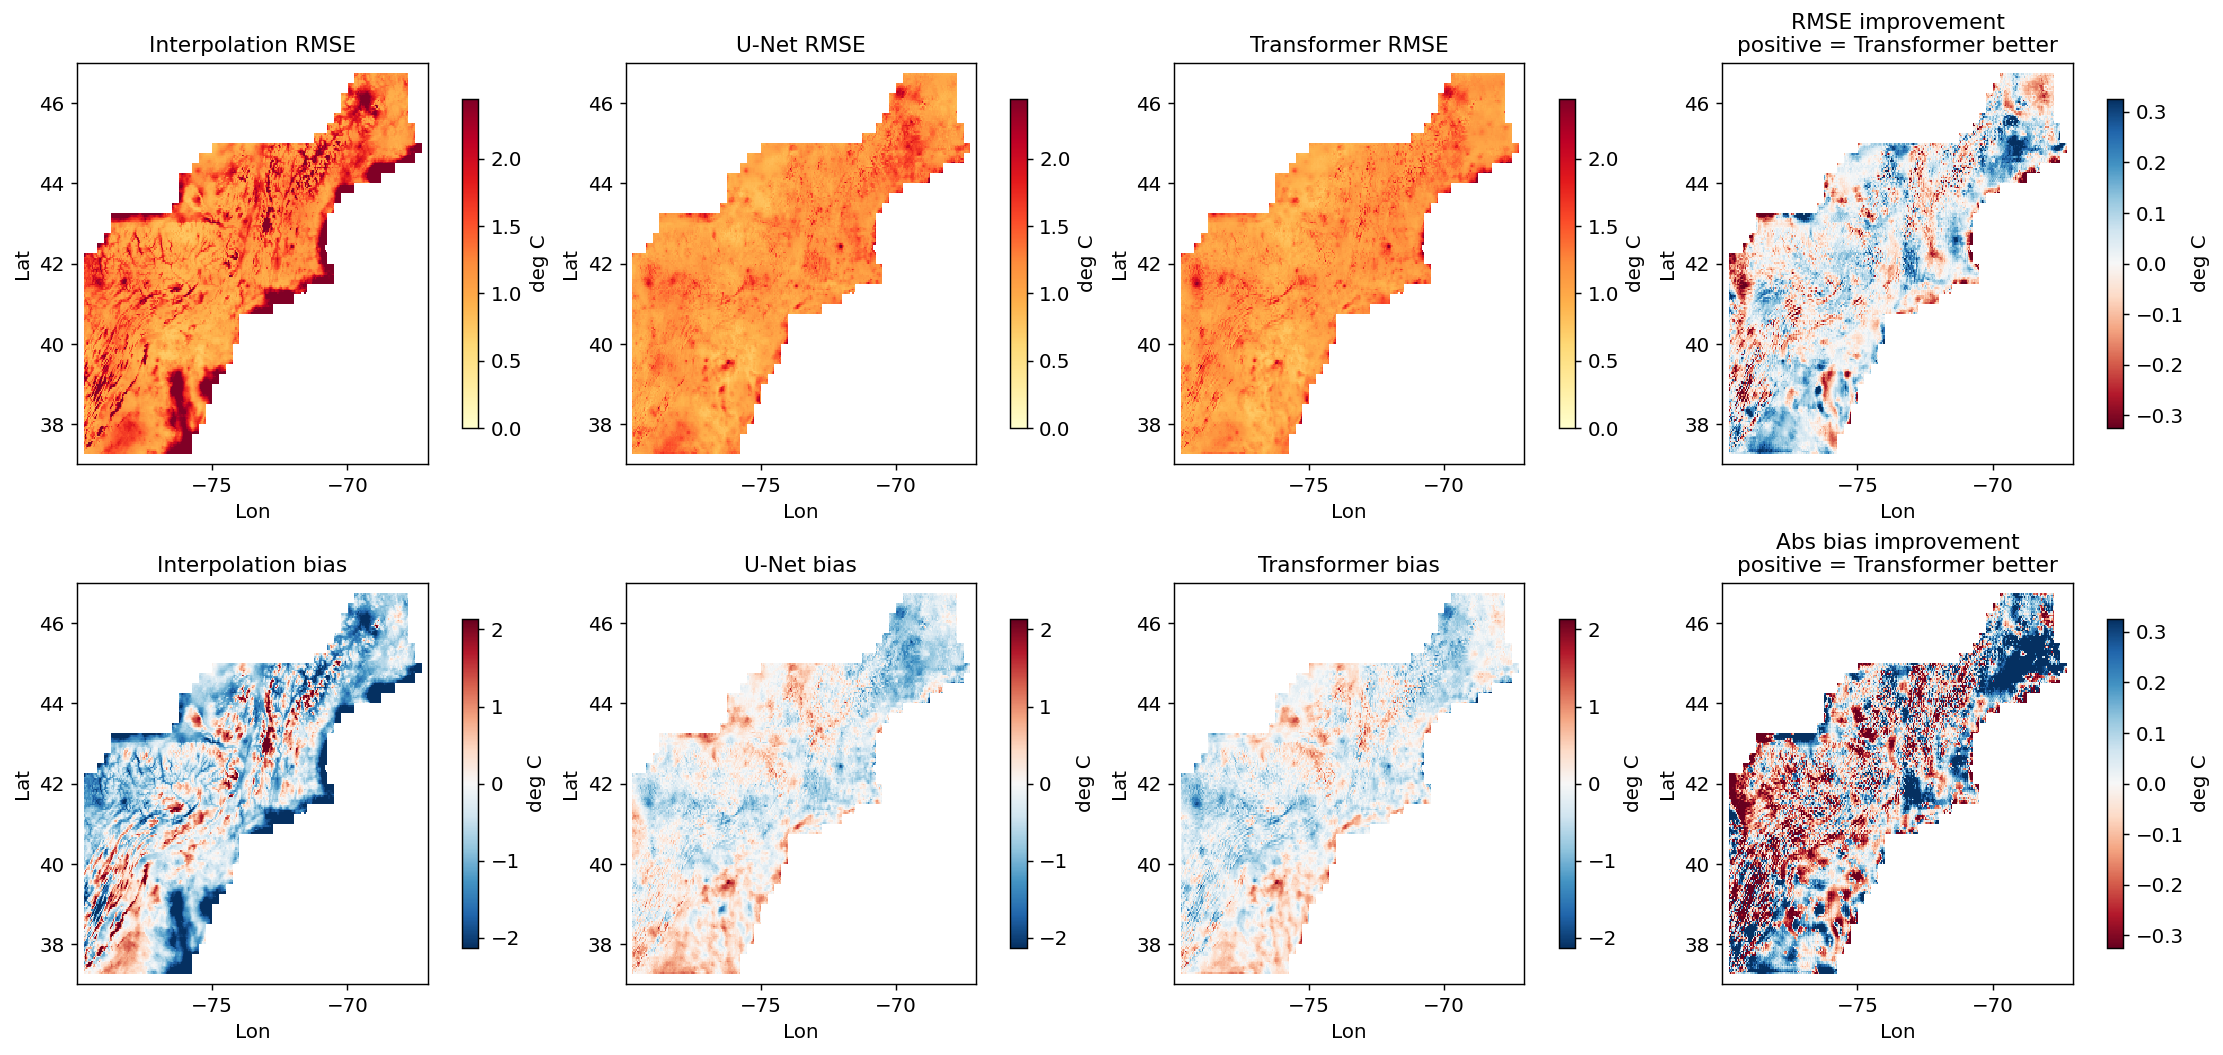

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(17, 8), constrained_layout=True)

rmse_vmax = np.nanpercentile(np.concatenate([da.values.ravel() for da in rmse_maps.values()]), 98)
bias_vmax = np.nanpercentile(np.abs(np.concatenate([da.values.ravel() for da in bias_maps.values()])), 98)
improve_vmax = np.nanpercentile(np.abs(tf_rmse_improve_vs_unet.values), 98)

top_panels = [
    (rmse_maps["Interpolation"], "Interpolation RMSE", "YlOrRd", 0, rmse_vmax),
    (rmse_maps["U-Net T+Elev"], "U-Net RMSE", "YlOrRd", 0, rmse_vmax),
    (rmse_maps["Transformer T+Elev"], "Transformer RMSE", "YlOrRd", 0, rmse_vmax),
    (tf_rmse_improve_vs_unet, "RMSE improvement\npositive = Transformer better", "RdBu", -improve_vmax, improve_vmax),
]
bottom_panels = [
    (bias_maps["Interpolation"], "Interpolation bias", "RdBu_r", -bias_vmax, bias_vmax),
    (bias_maps["U-Net T+Elev"], "U-Net bias", "RdBu_r", -bias_vmax, bias_vmax),
    (bias_maps["Transformer T+Elev"], "Transformer bias", "RdBu_r", -bias_vmax, bias_vmax),
    (tf_abs_bias_improve_vs_unet, "Abs bias improvement\npositive = Transformer better", "RdBu", -improve_vmax, improve_vmax),
]

for row_axes, panels in zip(axes, [top_panels, bottom_panels]):
    for ax, (da, title, cmap, vmin, vmax) in zip(row_axes, panels):
        pcm = ax.pcolormesh(da["lon"], da["lat"], da.values, shading="auto", cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.set_xlabel("Lon")
        ax.set_ylabel("Lat")
        cb = plt.colorbar(pcm, ax=ax, shrink=0.82)
        cb.set_label("deg C")

plt.savefig(fig_dir / "spatial_rmse_bias_maps.png", bbox_inches="tight", dpi=300)
plt.show()

In [4]:
features = xr.Dataset(coords={"lat": mask["lat"], "lon": mask["lon"]})
for var in ["elevation", "slope", "aspect_sin", "aspect_cos", "roughness", "local_relief"]:
    if var in ds_topo:
        features[var] = ds_topo[var].interp(lat=mask["lat"], lon=mask["lon"], method="nearest")
features["urban_fraction"] = ds_urban["urban_fraction"].interp(lat=mask["lat"], lon=mask["lon"], method="nearest")

records = {}
valid = mask.values.astype(bool)
for var in features.data_vars:
    records[var] = features[var].where(mask).values[valid]

for name in models:
    records[f"{name} RMSE"] = rmse_maps[name].values[valid]
    records[f"{name} Bias"] = bias_maps[name].values[valid]
records["Transformer RMSE improvement vs U-Net"] = tf_rmse_improve_vs_unet.values[valid]
records["Transformer abs bias improvement vs U-Net"] = tf_abs_bias_improve_vs_unet.values[valid]

feature_df = pd.DataFrame(records).replace([np.inf, -np.inf], np.nan).dropna()
feature_df.head()

,elevation,slope,aspect_sin,aspect_cos,roughness,local_relief,urban_fraction,Interpolation RMSE,Interpolation Bias,U-Net T+Elev RMSE,U-Net T+Elev Bias,Transformer T+Elev RMSE,Transformer T+Elev Bias,Transformer RMSE improvement vs U-Net,Transformer abs bias improvement vs U-Net
0,354.250227,0.009461,0.548417,-0.419322,25.898658,102.250244,0.0,1.445306,-1.127468,1.048100,-0.479064,1.207075,-0.791807,-0.158975,-0.312742
1,348.998631,0.010548,0.147373,0.985751,34.575275,152.000378,0.0,1.345120,-0.979425,1.024020,-0.341018,1.117991,-0.577749,-0.093971,-0.236731
2,308.750079,0.011988,-0.294999,0.380452,41.464965,164.000000,0.0,1.466745,-1.157743,0.971267,-0.364158,1.147850,-0.662939,-0.176583,-0.298781
3,329.503179,0.018602,-0.709999,-0.267065,43.572097,164.000000,0.0,1.249321,-0.877636,0.964676,-0.364525,1.012936,-0.434260,-0.048260,-0.069735
4,371.253501,0.011356,-0.749152,-0.153432,46.411256,164.000000,0.0,0.998382,-0.446170,0.914585,-0.147885,0.921367,-0.109239,-0.006783,0.038646


In [5]:
target_cols = [
    "U-Net T+Elev RMSE", "Transformer T+Elev RMSE",
    "U-Net T+Elev Bias", "Transformer T+Elev Bias",
    "Transformer RMSE improvement vs U-Net",
]
feature_cols = list(features.data_vars)

corr = feature_df[feature_cols + target_cols].corr(method="spearman").loc[feature_cols, target_cols]
display(corr)
corr.to_csv(fig_dir / "spearman_feature_error_correlations.csv")

,U-Net T+Elev RMSE,Transformer T+Elev RMSE,U-Net T+Elev Bias,Transformer T+Elev Bias,Transformer RMSE improvement vs U-Net
elevation,-0.030742,0.030213,-0.116304,-0.202272,-0.101480
slope,0.094148,0.134018,-0.144251,-0.211315,-0.065813
aspect_sin,0.040862,0.027770,-0.040030,-0.009955,0.023294
aspect_cos,0.101592,0.079144,-0.014812,-0.004596,0.041979
roughness,0.101366,0.138950,-0.136788,-0.213421,-0.064654
local_relief,0.107154,0.141989,-0.139601,-0.214553,-0.060230
urban_fraction,-0.165306,-0.133362,0.093853,0.024259,-0.063829


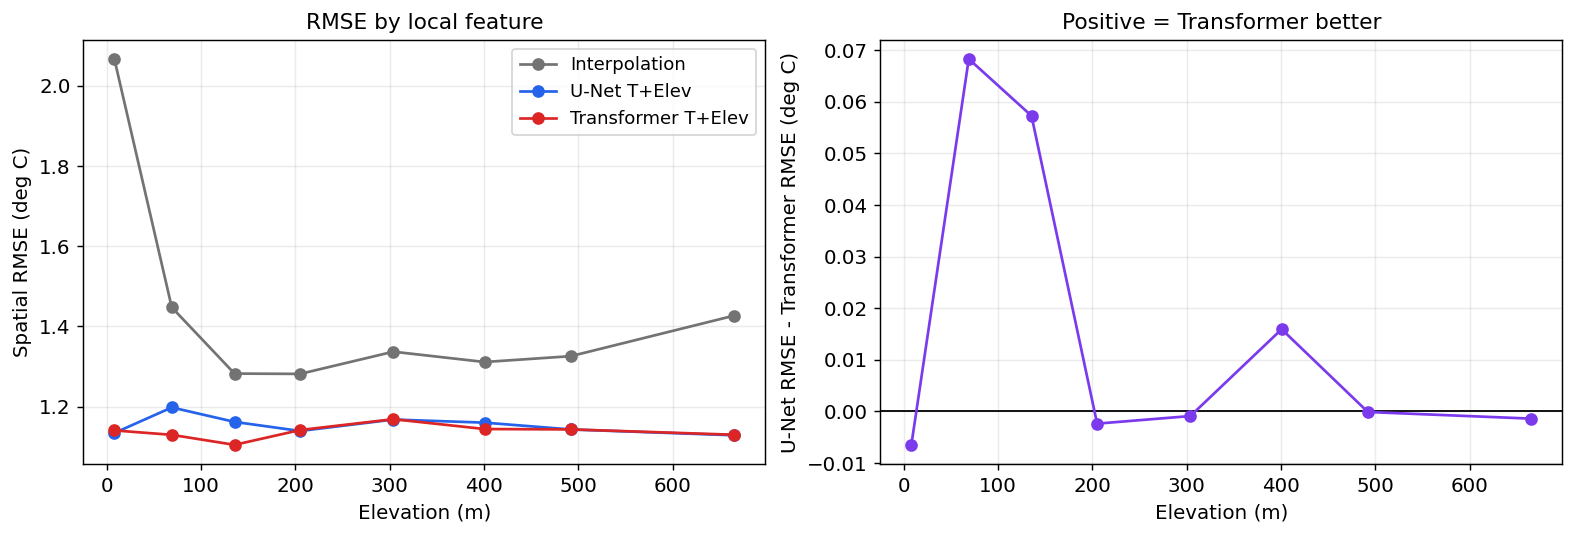

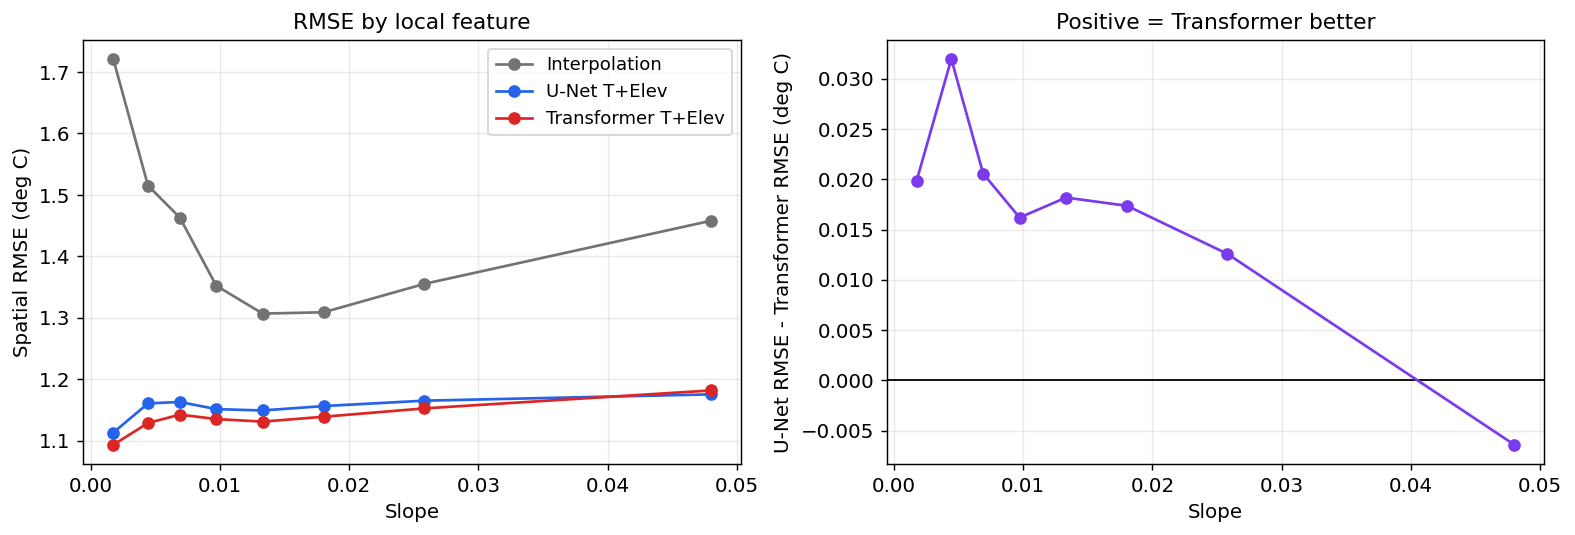

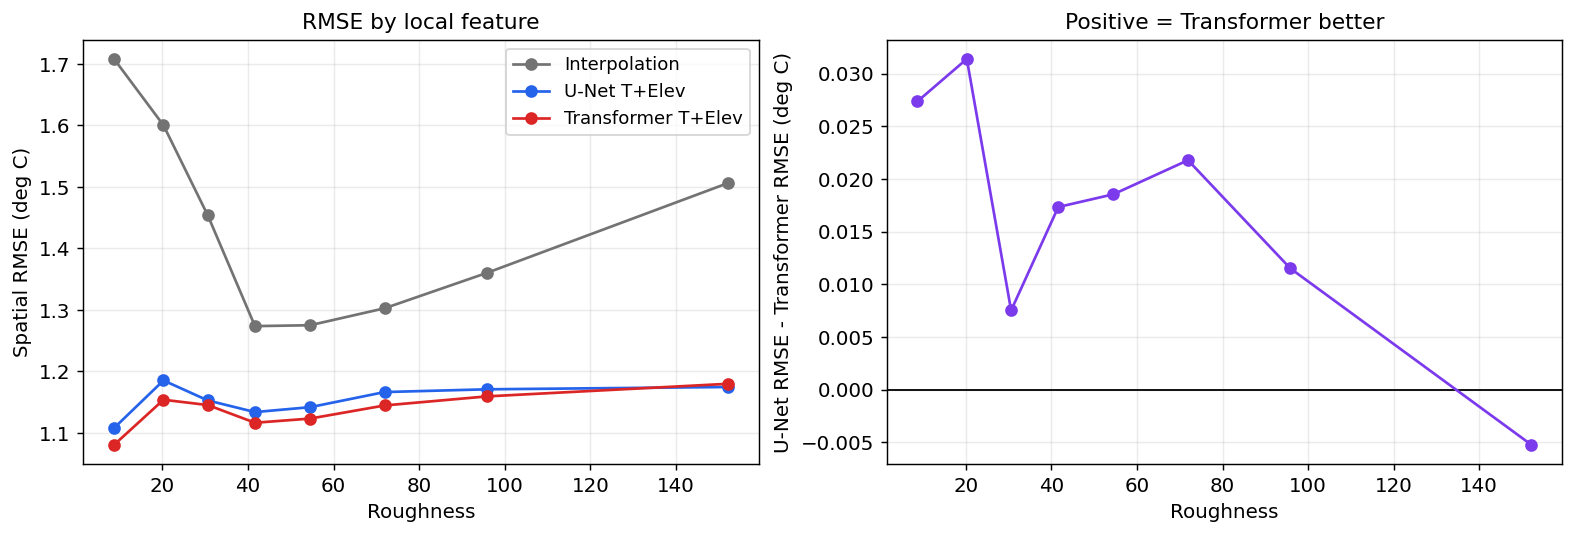

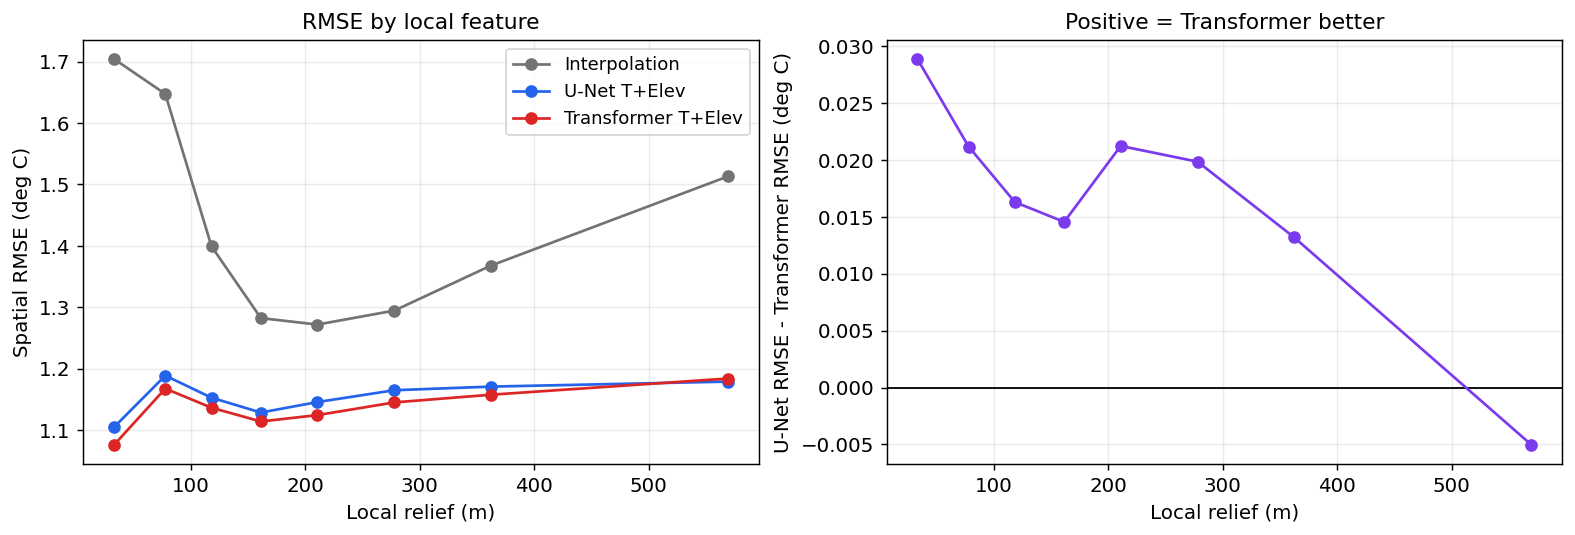

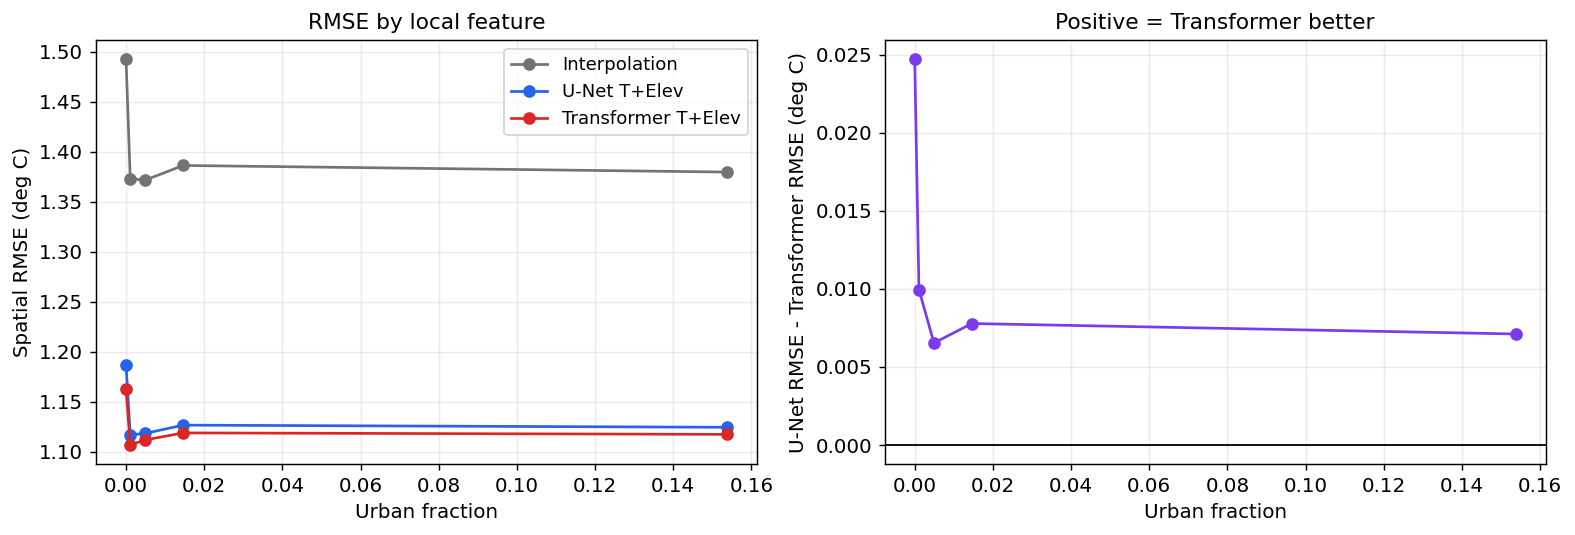

In [6]:
def plot_binned_feature(feature, xlabel, filename, bins=8):
    df = feature_df.copy()
    df["bin"] = pd.qcut(df[feature], q=bins, duplicates="drop")
    grouped = df.groupby("bin", observed=True)
    x = grouped[feature].mean()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
    for name, color in [("Interpolation", "0.45"), ("U-Net T+Elev", "#2563EB"), ("Transformer T+Elev", "#DC2626")]:
        y = grouped[f"{name} RMSE"].mean()
        axes[0].plot(x, y, marker="o", label=name, color=color)
    axes[0].set_xlabel(xlabel)
    axes[0].set_ylabel("Spatial RMSE (deg C)")
    axes[0].set_title("RMSE by local feature")
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    axes[1].axhline(0, color="k", linewidth=1)
    axes[1].plot(x, grouped["Transformer RMSE improvement vs U-Net"].mean(), marker="o", color="#7C3AED")
    axes[1].set_xlabel(xlabel)
    axes[1].set_ylabel("U-Net RMSE - Transformer RMSE (deg C)")
    axes[1].set_title("Positive = Transformer better")
    axes[1].grid(alpha=0.25)

    plt.savefig(fig_dir / filename, bbox_inches="tight", dpi=300)
    plt.show()

plot_binned_feature("elevation", "Elevation (m)", "rmse_by_elevation.png")
plot_binned_feature("slope", "Slope", "rmse_by_slope.png")
plot_binned_feature("roughness", "Roughness", "rmse_by_roughness.png")
plot_binned_feature("local_relief", "Local relief (m)", "rmse_by_local_relief.png")
plot_binned_feature("urban_fraction", "Urban fraction", "rmse_by_urban_fraction.png")

In [7]:
for name in ["U-Net T+Elev", "Transformer T+Elev"]:
    feature_df[f"{name} high RMSE"] = feature_df[f"{name} RMSE"] >= feature_df[f"{name} RMSE"].quantile(0.90)

rows = []
for name in ["U-Net T+Elev", "Transformer T+Elev"]:
    high = feature_df[feature_df[f"{name} high RMSE"]]
    rest = feature_df[~feature_df[f"{name} high RMSE"]]
    for feat in feature_cols:
        rows.append({
            "Model": name,
            "Feature": feat,
            "Top 10% RMSE mean": high[feat].mean(),
            "Other cells mean": rest[feat].mean(),
            "Difference high-minus-other": high[feat].mean() - rest[feat].mean(),
        })

hotspot_feature_table = pd.DataFrame(rows)
display(hotspot_feature_table)
hotspot_feature_table.to_csv(fig_dir / "high_rmse_hotspot_feature_summary.csv", index=False)
feature_df.to_csv(fig_dir / "gridcell_feature_error_table.csv", index=False)

,Model,Feature,Top 10% RMSE mean,Other cells mean,Difference high-minus-other
0,U-Net T+Elev,elevation,246.947139,289.179207,-42.232068
1,U-Net T+Elev,slope,0.015567,0.016047,-0.000480
2,U-Net T+Elev,aspect_sin,0.079130,0.035324,0.043806
3,U-Net T+Elev,aspect_cos,0.126455,0.028384,0.098071
4,U-Net T+Elev,roughness,57.501660,59.666612,-2.164952
5,U-Net T+Elev,local_relief,219.255174,227.157784,-7.902609
6,U-Net T+Elev,urban_fraction,0.012234,0.022863,-0.010629
7,Transformer T+Elev,elevation,297.865139,283.521256,14.343883
8,Transformer T+Elev,slope,0.019185,0.015645,0.003541
9,Transformer T+Elev,aspect_sin,0.064693,0.036928,0.027765
